## How well do jobs and skills pay for Data Engineers?

#### Methology
1. Evaluate median salary for top 6 data jobs
2. Find median salary per skill for Data Engineer
3. Visualize for highest paying and most demanded skills 

In [15]:
# Importing Libraries
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
from matplotlib import cm
import ast
import seaborn as sns

# Loading Data
df = pd.read_csv('C:/Users/david/Desktop/job_postings_flat.csv')

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [16]:
df_Ger = df[df['job_country'] == 'Germany'].dropna(subset=['salary_year_avg']) 

In [17]:
job_titles = df_Ger['job_title_short'].value_counts().index[:5].tolist()


In [18]:
job_ger_top5 = df_Ger[df_Ger['job_title_short'].isin(job_titles)]

job_titles

['Data Analyst',
 'Data Scientist',
 'Machine Learning Engineer',
 'Data Engineer',
 'Senior Data Engineer']

C:\Users\david\AppData\Local\Temp\ipykernel_24668\3248793511.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=job_ger_top5, x='salary_year_avg', y='job_title_short', palette='crest')


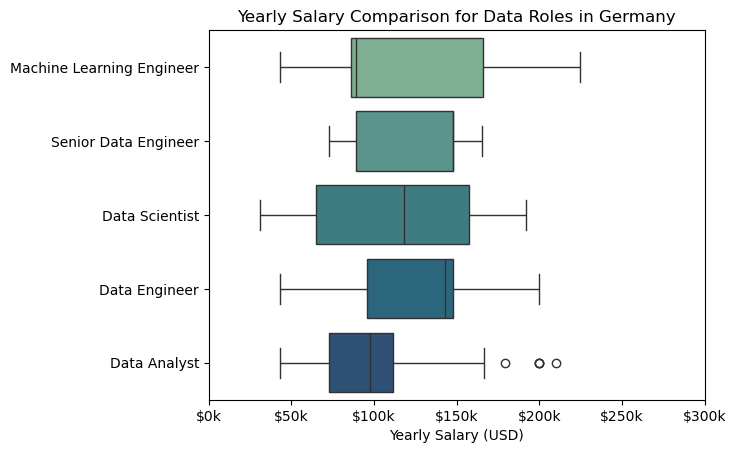

In [19]:
sns.boxplot(data=job_ger_top5, x='salary_year_avg', y='job_title_short', palette='crest')
plt.title('Yearly Salary Comparison for Data Roles in Germany')
plt.xlabel('Yearly Salary (USD)')
plt.ylabel('')
plt.xlim(0, 300000)
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}k'))
plt.show()

In [20]:
df_DA_Ger = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'Germany')].copy()

df_DA_Ger = df_DA_Ger.dropna(subset='salary_year_avg')

In [21]:
df_DA_Ger = df_DA_Ger.explode('job_skills')

df_DA_Ger[['salary_year_avg' , 'job_skills']].head()

,salary_year_avg,job_skills
46268,102500.0,sql
46268,102500.0,tableau
46268,102500.0,atlassian
54144,166419.5,python
54144,166419.5,nosql


In [22]:
df_DA_top_pay = df_DA_Ger.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by='median', ascending=False)

df_DA_top_pay = df_DA_top_pay.head(10)

df_DA_top_pay

,count,median
job_skills,,
mysql,1,210000.0
github,3,199675.0
nosql,1,166419.5
terraform,1,166419.5
redshift,1,166419.5
kafka,1,166419.5
gcp,3,165000.0
airflow,1,138000.0
bigquery,3,138000.0


In [23]:
df_DA_most_pop = df_DA_Ger.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by='count', ascending=False)

df_DA_most_pop = df_DA_most_pop.head(10).sort_values(by='median', ascending=False)

df_DA_most_pop

,count,median
job_skills,,
spark,10,105587.50
python,26,103325.00
tableau,15,100500.00
sql,30,100250.00
power bi,6,93200.00
excel,9,90000.00
r,8,88033.75
azure,6,87987.50
looker,7,60000.00


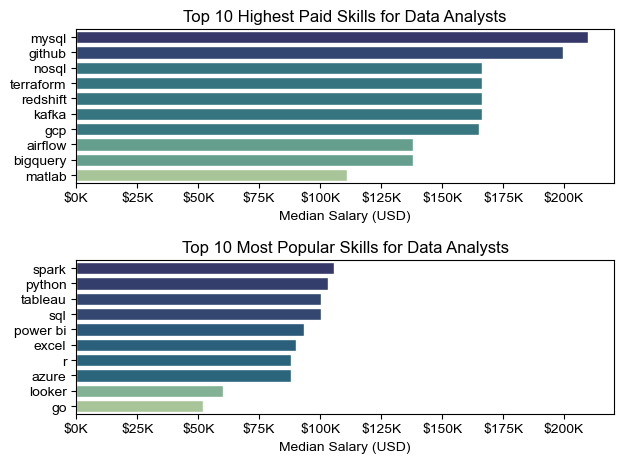

In [24]:
fig, ax = plt.subplots(2,1)
sns.set_theme(style='ticks')

# Top 10 Highest Paid Skills for Data Analysts (Germany)
sns.barplot(data=df_DA_top_pay, x='median', y=df_DA_top_pay.index, hue='median', ax=ax[0], palette='crest')
ax[0].legend().remove()
ax[0].set_title('Top 10 Highest Paid Skills for Data Analysts')
ax[0].set_ylabel('')
ax[0].set_xlabel('Median Salary (USD)')
ax[0].set_xlim(ax[0].get_xlim())
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))

sns.barplot(data=df_DA_most_pop, x='median', y=df_DA_most_pop.index, hue='median', ax=ax[1], palette='crest')
ax[1].legend().remove()
ax[1].set_title('Top 10 Most Popular Skills for Data Analysts')
ax[1].set_ylabel('')
ax[1].set_xlabel('Median Salary (USD)')
ax[1].set_xlim(ax[0].get_xlim())
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))

plt.tight_layout()
plt.show()
